# Assignment-6

This notebook contains the questions to test the proficiency in `Statistics`.

### Date: 1st February, 2026

### Steps to solve and upload the assignment 

- Download the notebook in your local machine.
- Solve the questions in the notebook and save it.
- Rename the file as `Assignment-06-<your_name>_<your_surname>.ipynb`. For example if your name is Dipika Chopra then name the file as `Assignment-06-Dipika_Chopra.ipynb`.
- For numerical problems you can either solve the same using using python in the solution notebook or you can solve it on paper and upload the scan pdf copy of the solution. 
- If you are solving it on paper then name the pdf file of the scan copy of the solution as `Assignment-06-<your_name>_<your_surname>.pdf`. For example if your name is Akash Kumar then name the file as `Assignment-06-Akash_Kumar.pdf`.
- Upload the solved notebook in your github repo under the folder **Assignment-6**.
- Upload the solved notebook and the scanned pdf copy of the solutions in the google drive location: https://drive.google.com/drive/folders/1YcMNgD9h_Kdh7-Q0no3xONNctBtzqcOJ?usp=sharing 
<h3><span style="color:red"> Deadline: 22nd February, 2026 </span></h3>

<h5><span style="color:blue"> <b>Instructions:</b> Please answer all the questions. For problems requiring numerical solutions, you are encouraged to write code in Python to compute the results. Show your steps and explain your reasoning. </span></h5>

### Problem-1

A startup company with 20 employees recorded their annual salaries (in INR Lakhs):
`[6.5, 7.2, 8.0, 6.8, 9.5, 7.0, 15.0, 7.5, 8.2, 6.9, 7.8, 10.5, 7.1, 8.5, 6.7, 7.3, 7.9, 9.0, 8.8, 7.6]`

(a) Calculate the mean, median, and mode of the salaries.

(b) Determine the range, variance, and standard deviation of the salaries.

(c) Calculate the Interquartile Range (IQR). What does the IQR tell you about the salary distribution?

(d) Construct a box plot for the salaries. Identify any potential outliers.


mean of salaries is  8.19
median of salaries is  7.7
mode of salaries is  6.5
Range of values 8.5
Std deviatio of values 1.85
Variance of  values 3.43
Interquartile Range is 1.7


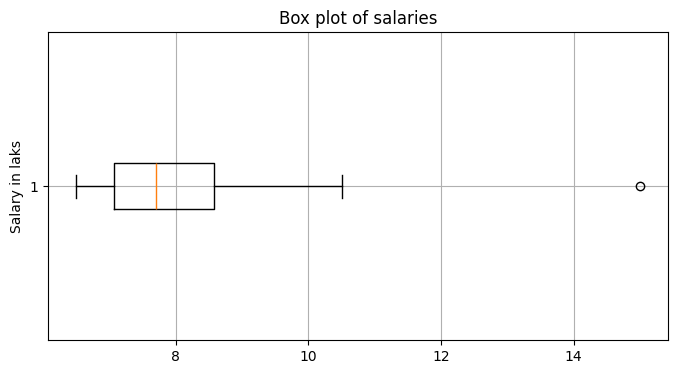

lower_threshold 4.47
upper_threshold 11.28
outlier [np.float64(15.0)]


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import statistics as stat
import pandas as pd

val = [6.5, 7.2, 8.0, 6.8, 9.5, 7.0, 15.0, 7.5, 8.2, 6.9, 7.8, 10.5, 7.1, 8.5, 6.7, 7.3, 7.9, 9.0, 8.8, 7.6]


print("mean of salaries is ",round(stat.mean(val),2))
print("median of salaries is ",round(stat.median(val),2))
print("mode of salaries is ",stat.mode(val))

sal_val = np.array(val)
print("Range of values" ,sal_val.max() - sal_val.min())
print("Std deviatio of values" ,round(sal_val.std(),2))
print("Variance of  values" ,round(sal_val.var(),2))

Q1, Q2, Q3 = stat.quantiles(sal_val)
IQR = Q3-Q1

print("Interquartile Range is" ,round((Q3 - Q1),2))

plt.figure(figsize=(8,4))
plt.boxplot(sal_val, vert=False)
plt.title("Box plot of salaries")
plt.ylabel("Salary in laks")
plt.grid()
plt.show()

lower_threshold = round(Q1 -1.5*IQR,2)
upper_threshold  = round(Q3 +1.5*IQR,2)
outlier_sal = [ x for x in sal_val  if x > upper_threshold  or x < lower_threshold]

print("lower_threshold",lower_threshold)
print("upper_threshold",upper_threshold)
print("outlier",outlier_sal)

### Problem-2

A tech company conducted a customer satisfaction survey, rating their latest product on a scale of 1 to 10 (10 being highly satisfied). The scores from 30 randomly selected customers are:
[7, 8, 9, 6, 7, 8, 10, 5, 7, 8, 9, 7, 6, 8, 7, 9, 10, 6, 7, 8, 5, 9, 8, 7, 6, 7, 8, 9, 7, 8]

(a) Create a frequency distribution table for these scores.

(b) Plot a histogram of the customer satisfaction scores. Describe the shape of the distribution (e.g., symmetric, skewed).

(c) Calculate the Pearson's (first and second) coefficients of skewness for this data. Interpret the values.

(d) Calculate the excess kurtosis for this data using sample kurtosis formula. What does the kurtosis value suggest about the tails of the distribution?


Frequency Table for the data : 
7     9
8     8
9     5
6     4
10    2
5     2
Name: count, dtype: int64


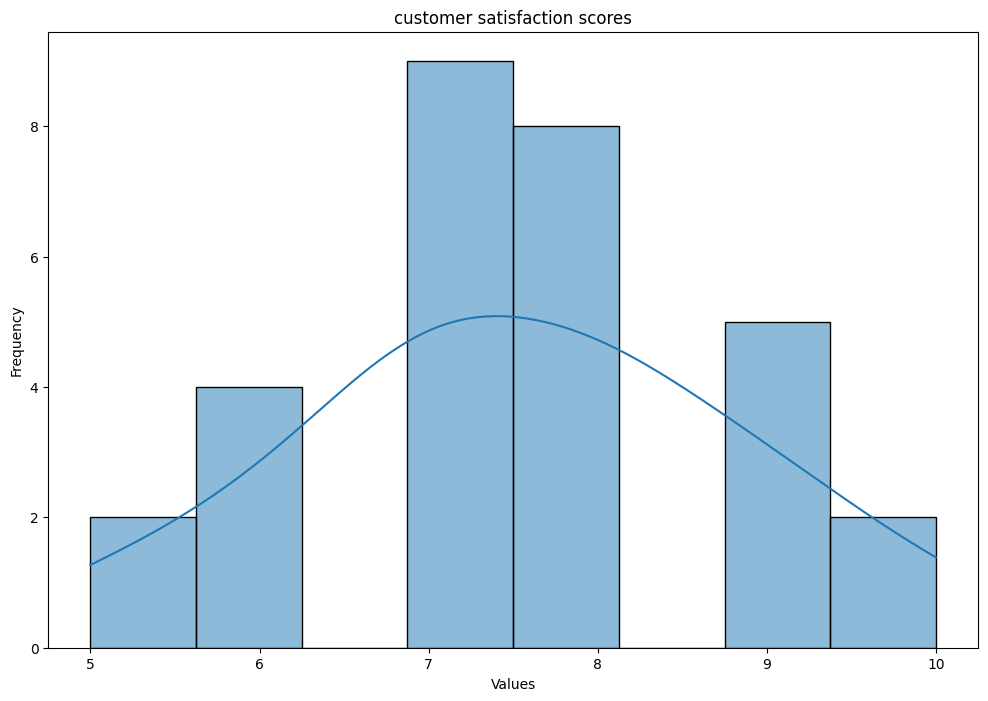

Pearson's first coefficient of skewness = 0.41,
Pearson's second coefficient of skewness = 0.08,
Bowley's coefficient of skewness = 0.20
Kurtosis value: 0
Excess Kurtosis value: -3


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import statistics as stat
import pandas as pd
import seaborn as sns
from scipy.stats import kurtosis
scores_data =  pd.Series([7, 8, 9, 6, 7, 8, 10, 5, 7, 8, 9, 7, 6, 8, 7, 9, 10, 6, 7, 8, 5, 9, 8, 7, 6, 7, 8, 9, 7, 8])

print("\nFrequency Table for the data : ")
print(scores_data.value_counts())

#plt.figure(figsize=(10,8))
#plt.hist(scores_data.values, edgecolor='k', bins=30)
#plt.xlabel('Values')
#plt.ylabel('Frequency')
#plt.show()

plt.figure(figsize=(12,8))
sns.histplot(scores_data.values, kde=True)
plt.title("customer satisfaction scores")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()


#skewness_measure
mean = scores_data.mean()
std = scores_data.std()
Q1, Q2, Q3 = stat.quantiles(scores_data)
mode = stat.mode(scores_data)

sk1 = (mean - mode)/std
sk2 = 3*(mean - Q2)/std

skb = (Q1+Q3 - 2*Q2)/(Q3-Q1)

print(f"Pearson's first coefficient of skewness = {sk1:.2f},\nPearson's second coefficient of skewness = {sk2:.2f},\nBowley's coefficient of skewness = {skb:.2f}")

kurtosis_value = kurtosis(scores_data,bias =False)
print("Kurtosis value:", round(kurtosis_value))
print("Excess Kurtosis value:", round(kurtosis_value-3))




### Problem-3

A marketing team wants to understand the relationship between their monthly advertising expenditure (in INR Lakhs) and corresponding sales revenue (in INR Lakhs) over the last 10 months.

| Month | Advertising Spend (X) | Sales Revenue (Y) |
|-------|-----------------------|-------------------|
|     1 |                     5 |                52 |
|     2 |                     7 |                65 |
|     3 |                     6 |                60 |
|     4 |                     8 |                70 |
|     5 |                     5 |                55 |
|     6 |                     9 |                75 |
|     7 |                     7 |                68 |
|     8 |                    10 |                80 |
|     9 |                     6 |                58 |
|    10 |                     8 |                72 |


(a) Calculate the covariance between advertising spend and sales revenue.

(b) Plot Sales Revenue vs Advertising spent.

(c) Calculate the Pearson correlation coefficient between advertising spend and sales revenue.

(d) Interpret the meaning of both the covariance and the correlation coefficient in the context of this data.

In [36]:
def covariance(X, Y):
    x_bar = X.mean()
    y_bar = Y.mean()
    n = X.shape[0]
    cov = ((X - x_bar) @ (Y - y_bar)) / n
    return cov

In [43]:
def correlation(X, Y):
    cov = covariance(X, Y)
    std_x = X.std()
    std_y = Y.std()
    corr = cov / (std_x * std_y)
    return corr

   Month  Advertising Spend (X)  Sales Revenue (Y)
0      1                      5                 52
1      2                      7                 65
2      3                      6                 60
3      4                      8                 70
4      5                      5                 55
5      6                      9                 75
6      7                      7                 68
7      8                     10                 80
8      9                      6                 58
9     10                      8                 72
covariance is  2.05


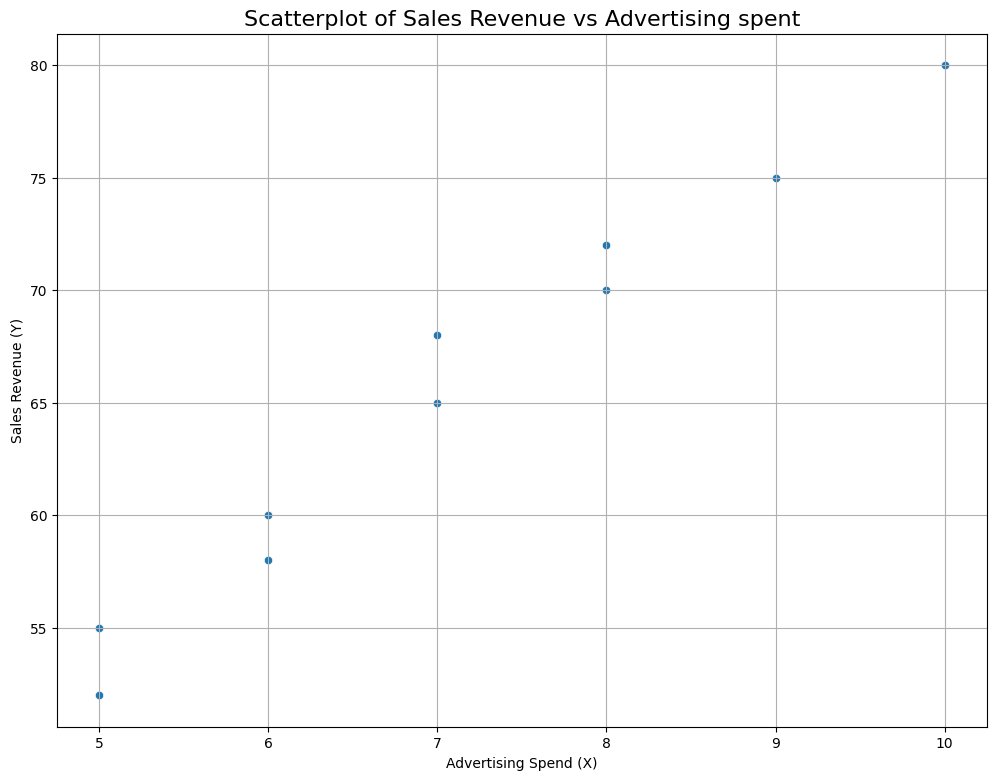

correlation is  0.8866847066096614
correlation coefficient is   [[1.         0.98520523]
 [0.98520523 1.        ]]


In [ ]:
data = {
    'Month': [1, 2, 3, 4, 5,6,7,8,9,10],
    'Advertising Spend (X)': [5,7,6,8,5,9,7,10,6,8],
    'Sales Revenue (Y)': [52,65,60,70,55,75,68,80,58,72]
}

df = pd.DataFrame(data)
print(df)
print("covariance is ",covariance(df["Month"].values,df["Advertising Spend (X)"].values))


plt.figure(figsize=(12,9))
sns.scatterplot(x = df["Advertising Spend (X)"], y = df["Sales Revenue (Y)"])
#plt.legend()
plt.title("Scatterplot of Sales Revenue vs Advertising spent", fontsize=16)
plt.grid()
plt.show()



print("correlation is ",correlation(df["Advertising Spend (X)"],df["Sales Revenue (Y)"]))

print("correlation coefficient is  ",np.corrcoef(df["Advertising Spend (X)"],df["Sales Revenue (Y)"]))


### Problem-4

A traffic department claims that the average daily commute time for residents in a certain city is 45 minutes. A researcher believes this claim is too low and collects data from a random sample of 100 residents. The sample mean commute time is 48 minutes with a standard deviation of 12 minutes.

(a) Formulate the null and alternative hypotheses for this scenario.

(b) Construct a 95% confidence interval for the true average daily commute time.

(c) Based on the confidence interval, what can you conclude about the traffic department's claim?

a) Hypothesis:

H0: Average daily commute time for residents in a certain city is mu =45

H1: Average daily commute time for residents in a certain city is greater than 45 mu >45

It is a one sided Hypothesis (right sided)

In [ ]:
#Construct a 95% confidence interval for the true average daily commute time.
from scipy import stats
import math
mu_bar = 48
mu= 45
SD= 12
n =100
SE = SD/math.sqrt(n)
z = (mu_bar-mu)/SE
print("z value is ",z)
#p=1-p(z) --right sided
p_value = 1 -stats.norm.cdf(z)

print("p value is ",p_value)
print("Since pvalue is less than significance value we reject the null Hypothesis ")
print("we can conclude that the traffic department's claim is true and mu is greater than 45")

z value is  2.5
p value is  0.006209665325776159
Since pvalue is less than significance value we reect the null Hypothesis 
we can conclude that the traffic department's claim is true and mu is greater than 45


### Problem-5

A manufacturing company wants to estimate the average number of units produced per hour by a new machine. They take 36 random observations and find the sample mean to be 150 units with a sample standard deviation of 15 units.

(a) What is the point estimate for the true average number of units produced per hour?

(b) Construct a 99% confidence interval for the true average number of units produced per hour.

(c) If the company wants to be 99% confident that their estimate is within 3 units of the true mean, what sample size would they need (assuming the same standard deviation)?

In [5]:
from scipy import stats
import math
print("the point estimate for the true average number of units produced per hour is same as sample mean 150")

# Construct a 99% confidence interval for the true average number of units produced per hour.

#confidence_interval is between mu_bar +t * sd/sqrt(n) and mu_bar -t * sd/sqrt(n) 
# confidence_interval = sample mean +- margin of error
mu_bar =150
n = 36
sd =15
confidence =.99
#standard error
SE = 15/math.sqrt(n)


#margin of error
df =n-1
t = stats.t.ppf((1- (1-confidence)/2),df)
me = t*SE

lower = mu_bar -me
upper = mu_bar +me

print("99% confidence interval ", (lower,upper))

#(c) If the company wants to be 99% confident that their estimate is within 3 units of the true mean, what sample size would they need (assuming the same standard deviation)?

  #margin of error =3
 #no of samples = (z*sd/e) **2
z_val =stats.norm.ppf(1-((1-confidence)/2))
E =3
req_n = ((z_val*sd)/E)**2

print("Required sample size is ", math.ceil(req_n))

the point estimate for the true average number of units produced per hour is same as sample mean 150
99% confidence interval  (np.float64(143.1904860269799), np.float64(156.8095139730201))
Required sample size is  166


### Problem-6

A website designer believes that a new website redesign will increase the average time users spend on the site. Before the redesign, the average time spent was 3.5 minutes. After the redesign, a random sample of 50 users showed an average time of 3.8 minutes with a standard deviation of 1.0 minute.

(a) Perform a one-sided hypothesis test at a 0.05 significance level to determine if the redesign significantly increased the average time spent.

(b) State your null and alternative hypotheses, calculate the test statistic, and determine the p-value.

(c) What is your conclusion regarding the website redesign's impact?

In [ ]:
from scipy import stats
import math
mu_bar = 3.8
mu= 3.5
SD= 1.0
n =50
SE = SD/math.sqrt(n)
z = (mu_bar-mu)/SE
print("z value is ",z)
#p=1-p(z) --right sided
p_value = 1 -stats.norm.cdf(z)

print("H0 :mu =3.5 ")

print("H1:mu >3.5 ")

print("p value is ",p_value)
print("Since pvalue is less than significance value we reject the null Hypothesis ")
print("we can conclude that the website redesign incresed the time users spend on the site")

z value is  2.1213203435596415
H0 :mu =3.5 
H1:mu >3.5 
p value is  0.01694742676234462
Since pvalue is less than significance value we reject the null Hypothesis 
we can conclude that the website redesign incresed the time users spend on the site


### Problem-7

A company implemented a new training program to improve employee productivity. To assess its effectiveness, 15 employees' productivity scores were recorded before and after the training program. The scores are as follows:

| Employee | Before Training | After Training |
|----------|-----------------|----------------|
|        1 |              65 |             70 |
|        2 |              70 |             72 |
|        3 |              60 |             68 |
|        4 |              75 |             73 |
|        5 |              80 |             85 |
|        6 |              68 |             70 |
|        7 |              72 |             75 |
|        8 |              62 |             65 |
|        9 |              78 |             80 |
|       10 |              70 |             72 |
|       11 |              66 |             69 |
|       12 |              73 |             76 |
|       13 |              64 |             67 |
|       14 |              71 |             74 |
|       15 |              69 |             71 |

(a) State the null and alternative hypotheses to test if the training program significantly improved productivity.

(b) Conduct a paired samples t-test at a 0.05 significance level. Calculate the test statistic and the p-value.

(c) Based on your analysis, did the training program effectively improve employee productivity?

H0 : There is no significant increase in employee productivity before and after the training program(mu_d=0)

H1: There is a significant increase in employee productivity before and after the training program(mu_d>0)

In [20]:

import numpy as np
import statistics as stat
import pandas as pd

data_Emp = {
    'Employee': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],
    'Before Training': [65,70,60,75,80,68,72,62,78,70,66,73,64,71,69],
     'After Training' : [70,72,68,73,85,70,75,65,80,72,69,76,67,74,71]
}

df_Emp = pd.DataFrame(data_Emp)
#print(df_Emp)
df_Emp['Difference'] = df_Emp['After Training'] -df_Emp['Before Training'] 
n=15
print(df_Emp)
mu_bar =np.mean(df_Emp['Difference'])
print(mu_bar)

std =np.std(df_Emp['Difference'],ddof=1)
print(std)
SE = std/math.sqrt(n)
print('SE',SE)
t= (mu_bar-0)/SE

print('t statistics ',t)

dof =n-1
confidence = .95
critical_val = stats.t.ppf((1- 0.05),dof)

print('critical_val ',critical_val)

print('since t statistics is greater than critical_val we reject the null Hypothesis,' \
'there is a significant increase in employee productivity before and after the training program')

    Employee  Before Training  After Training  Difference
0          1               65              70           5
1          2               70              72           2
2          3               60              68           8
3          4               75              73          -2
4          5               80              85           5
5          6               68              70           2
6          7               72              75           3
7          8               62              65           3
8          9               78              80           2
9         10               70              72           2
10        11               66              69           3
11        12               73              76           3
12        13               64              67           3
13        14               71              74           3
14        15               69              71           2
2.933333333333333
2.1201976547572388
SE 0.5474326805028539
t statistics 

### Problem-8

A battery manufacturer claims that their new 'ProLife' battery lasts longer than their existing 'Standard' battery. A consumer watchdog organization tests 40 'ProLife' batteries and 50 'Standard' batteries. The results are:

ProLife: Sample mean life = 120 hours, Sample standard deviation = 10 hours

Standard: Sample mean life = 115 hours, Sample standard deviation = 12 hours

(a) State the null and alternative hypotheses for testing the manufacturer's claim.

(b) Perform a t-test for two independent means at a 0.02 significance level.

(c) What is your conclusion regarding the manufacturer's claim about the 'ProLife' battery?

H0 : The battery life of ProLife doesnot last longer than Standard battery. 

H1: The battery life of ProLife  lasts longer than Standard battery.

In [11]:
from scipy import stats
import math
n1 =40
n2 =50
x1 =120
x2 =115
s1 =10
s2=12

t = (x1-x2)/(math.sqrt((s1**2/n1) +(s2**2/n2)))

print("t val",t)

dof = (((s1**2/n1) +(s2**2/n2))**2)/((((s1**2/n1)**2)/(n1-1)) +(((s2**2/n2)**2)/(n2-1)))
print("dof val",dof)
p_val = 1- stats.t.cdf(t,dof)

print('p_val',p_val)

print('As t val is greater than critical value, we reject the null hypothesis and ProLife  lasts longer than Standard battery')

t val 2.1556530677961345
dof val 87.8354340166509
p_val 0.01692266085894678
As t val is greater than critical value, we reject the null hypothesis and ProLife  lasts longer than Standard battery


### Problem-9

A popular restaurant chain claims that the average waiting time for a table on weekends is no more than 20 minutes. A local food critic believes it's longer. They record the waiting times (in minutes) for 30 randomly selected tables on various weekends:

`[22, 25, 18, 30, 28, 20, 23, 26, 19, 32, 21, 24, 27, 29, 20, 25, 23, 17, 31, 26, 22, 28, 20, 24, 27, 29, 21, 23, 25, 26]`

(a) Calculate the sample mean and sample standard deviation of the waiting times.

(b) Conduct a one-sided t-test at a 0.01 significance level to assess the food critic's belief.

(c) State your null and alternative hypotheses, calculate the test statistic, and determine the critical value.

(d) Based on your findings, what can you tell the food critic?

In [24]:
import numpy as np
import statistics as static
import math

waiting_time = [22, 25, 18, 30, 28, 20, 23, 26, 19, 32, 21, 24, 27, 29, 20, 25, 23, 17, 31, 26, 22, 28, 20, 24, 27, 29, 21, 23, 25, 26]


waiting_array = np.array(waiting_time)
print("sample mean is ",np.mean(waiting_array))
print("sample standard deviation ",np.std(waiting_array))
x_bar =np.mean(waiting_array)
x=20
std = np.std(waiting_array,ddof=1)
n=30
df =n-1
confidence =.01

t_Stats =  (x_bar -x)/(std/math.sqrt(n))

print("t value is ",t_Stats)
critical_val = stats.t.ppf((1- 0.01),df)
print('critical_val',critical_val)

print("H0 : Average waiting time is 20 mins.")

print("H1: Average waiting time is more than 20 mins")

if t_Stats >critical_val:
   print("Reject the null hypothesis")
else :
   print("Fail to reject the null hypothesis")


print("Food Crticis belief is supported")

sample mean is  24.366666666666667
sample standard deviation  3.859907886062683
t value is  6.0921711999214265
critical_val 2.4620213601503833
H0 : Average waiting time is 20 mins.
H1: Average waiting time is more than 20 mins
Reject the null hypothesis
Food Crticis belief is supported


### Problem-10

A software company is launching a new application and offers three different subscription tiers (Basic, Premium, Elite), each with varying features. Before the full launch, they conduct a pilot study to see if there's an association between a customer's age group and their preferred subscription tier. They surveyed 300 randomly selected potential customers and recorded their age group and preferred tier:

| Age Group   | Basic | Premium | Elite | Total |
|-------------|-------|---------|-------|-------|
| 18-29 years |    45 |      60 | 15    | 120   |
| 30-49 years |    30 |      50 | 20    | 100   |
|   50+ years |    25 |      40 | 15    | 80    |
|       Total |   100 |     150 | 50    | 300   |


(a) State the null and alternative hypotheses for the test of independence in this context.

(b) Calculate the expected frequencies for each cell in the table, assuming the null hypothesis is true. Show your calculations clearly.

(c) Calculate the chi-square test statistic.

(d) Using a significance level of α=0.05, determine the critical value for this test.

(e) What is your conclusion? Is there a significant association between a customer's age group and their preferred subscription tier? Justify your answer based on your calculated chi-square statistic and the critical value.

H0: "Age has no effect on the Subscriptions"

H1: "Age has  effect on the Subscriptions, these are dependent"

In [43]:

import numpy as np
import statistics as stat
import pandas as pd
from scipy.stats import chi2_contingency
alpha = 0.05


observed = np.array ([
[45,30,25],
[60,50,40],
[15,20,15]])
chi2_test_result = chi2_contingency(observed)
print("Chi-sqware statistics :",chi2_test_result.statistic )
print("Degrees of freedom :",chi2_test_result.dof )
print("pvalue :",chi2_test_result.pvalue )
print("Expected freq :",chi2_test_result.expected_freq )

if chi2_test_result.pvalue < alpha:
    print("Reject the null hypothesis")
else:
    print("fail to reject the null hypothesis")

Chi-sqware statistics : 3.1874999999999996
Degrees of freedom : 4
pvalue : 0.5269522746367856
Expected freq : [[40.         33.33333333 26.66666667]
 [60.         50.         40.        ]
 [20.         16.66666667 13.33333333]]
fail to reject the null hypothesis


### Bonus Problem

An e-commerce company is testing two different designs for its product pages (Design A and Design B) to see if one leads to significantly higher conversion rates (percentage of visitors who make a purchase). They randomly assigned 50,000 website visitors to see Design A and another 50,000 visitors to see Design B over a two-week period. At the end of the period, they collected data on the conversion rates. Due to data collection specifics, they have daily average conversion rates for 30 randomly selected days for each design, rather than individual visitor data.

Here are the summary statistics for the daily average conversion rates (in percentage points):

* Design A (Sample 1):

    - Number of days ($n_A$) = 30
    - Mean Daily Conversion Rate ($\bar{x}_A$) = 2.85%
    - Sample Standard Deviation ($s_A$) = 0.45%

* Design B (Sample 2):

    - Number of days ($n_B$) = 30
    - Mean Daily Conversion Rate ($\bar{x}_B$) = 3.05%
    - Sample Standard Deviation ($s_B$) = 0.60%

The company is concerned that the variability in conversion rates might differ between the two designs due to different aesthetic elements or backend processes.

(a) State the null and alternative hypotheses to test if there is a significant difference in the average daily conversion rates between Design A and Design B. (Consider a two-tailed test, as they are looking for any significant difference).

(b) Before performing the t-test, you need to decide whether to assume equal or unequal population variances. For the purpose of this problem, assume that a prior test suggests equal population variances.

(c) Calculate the appropriate test statistic (t-value) for comparing the two independent means, assuming equal population variances. Show all steps of your calculation.

(d) Determine the degrees of freedom for this test. 

(e) Using a significance level of α=0.05, determine the critical value(s) for your test.

(f) Based on your calculated test statistic and the critical value(s), what is your conclusion? Is there a statistically significant difference in the average daily conversion rates between Design A and Design B?

(g) Construct a 95% confidence interval for the difference between the true mean daily conversion rates $(μ_B - μ_A)$. Interpret this interval in the context of the problem.

(h) Show all the steps when a prior test suggests unequal population variances.

print("H0 :The daily average between Design A and Design B is same mua =mub")

print("H1: The daily average between Design A and Design B is not same mua <> mub")

In [58]:
#pooled variance
import numpy as np
import statistics as static
import math

n1=30
mu_a =2.85
s1 = .45

mu_b =3.05
s2= .60
n2=30
alpha =.05


pooled_sd = math.sqrt((((n1-1)*(s1**2))+(n2-1)*(s2**2))/(n1+n2-2))
print("pooled variance is" ,pooled_sd )

t_stats = (mu_a -mu_b)/ (pooled_sd*math.sqrt((1/n1)+(1/n2)))

print("t statistics " ,t_stats )

dof = n1+n2-2

print("dof " ,dof )

critical_val = stats.t.ppf((1 - alpha / 2),dof)

print("critical_val " ,critical_val )

if critical_val < alpha :
      print("Reject the null hypothesis")
else:
    print("fail to reject the null hypothesis")


pooled variance is 0.5303300858899106
t statistics  -1.4605934866804415
dof  58
critical_val  2.0017174841452356
fail to reject the null hypothesis


In [61]:
#Confidence interval of 95%

t_critical = stats.t.ppf(1-0.05/2,dof)
SE = pooled_sd*math.sqrt(1/n1+1/n2)

margin = t_critical* SE

lower = (mu_a -mu_b) -margin

upper = (mu_a -mu_b) +margin

print("95 % confidence interval", (round(lower,2),round(upper,2)))

95 % confidence interval (np.float64(-0.47), np.float64(0.07))


In [63]:
#unequal population variance

t_un = (mu_a-mu_b)/(math.sqrt((s1**2/n1) +(s2**2/n2)))

print("t unequal population variance val",t_un)

dof = (((s1**2/n1) +(s2**2/n2))**2)/((((s1**2/n1)**2)/(n1-1)) +(((s2**2/n2)**2)/(n2-1)))
print("dof val",dof)
p_val = stats.t.ppf((1 - alpha / 2),dof)

print('p_val',p_val)

if p_val < alpha :
      print("Reject the null hypothesis")
else:
    print("fail to reject the null hypothesis")

t unequal population variance val -1.4605934866804409
dof val 53.78338278931752
p_val 2.005064236429221
fail to reject the null hypothesis
